In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from UtilsRF import scorer

## Error analysis

First let us investigate the model selected using the TACREV data for validation and test.

Note that, the TACREV test set does NOT contain relation per:country_of_birth

In [51]:
# Read data from the text file into a DataFrame
file_path = "predictions_tacrev.txt"

In [45]:
error_df = pd.read_csv(file_path, sep="\t")
error_df.reset_index(inplace=True)  # add index column

In [52]:
summary_data = scorer.score(
    error_df["Gold Label"], error_df["Prediction"], verbose=True, return_data=True
)

Per-relation statistics:
org:alternate_names                  P:  77.29%  R:  79.18%  F1:  78.23%  #: 245
org:city_of_headquarters             P:  58.68%  R:  79.78%  F1:  67.62%  #: 89
org:country_of_headquarters          P:  36.70%  R:  43.48%  F1:  39.80%  #: 92
org:dissolved                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 1
org:founded                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 37
org:founded_by                       P: 100.00%  R:   0.00%  F1:   0.00%  #: 76
org:member_of                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 4
org:members                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 16
org:number_of_employees/members      P:   9.38%  R:  21.43%  F1:  13.04%  #: 14
org:parents                          P:  12.12%  R:   7.02%  F1:   8.89%  #: 57
org:political/religious_affiliation  P:  18.18%  R:  20.00%  F1:  19.05%  #: 10
org:shareholders                     P: 100.00%  R:   0.00%  F1:   0.00%  #: 3
org:stateorprovin

In [34]:
# We have count of occurrences if each relation in the test set. We add to the table also the count of occurences in the training set
with open("../../../data/tacred/json/train.json", "r") as file:
    data_train = json.load(file)
training_data = pd.json_normalize(data_train)

# Count occurrences of each relation in the training set
relation_counts = training_data["relation"].value_counts()
relation_counts = relation_counts.sort_index()

In [47]:
relation_counts = relation_counts[
    (relation_counts.index != "per:country_of_birth")
    & (relation_counts.index != "no_relation")
]

In [54]:
summary_data["train_counts"] = list(relation_counts)
summary_data["train_%"] = (
    summary_data["train_counts"] / sum(summary_data["train_counts"]) * 100
)
summary_data["test_%"] = (
    summary_data["test_counts"] / sum(summary_data["test_counts"]) * 100
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_18348\2542179993.py:20: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  bar_positions = range(len(df['Relation'][0:25]))
C:\Users\Hp\AppData\Local\Temp\ipykernel_18348\2542179993.py:21: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  bars = plt.bar(bar_positions[0:25],(df['train_%'][0:25]), color=colors, alpha=0.7)
C:\Users\Hp\AppData\Local\Temp\ipykernel_18348\2542179993.py:24: FutureWarning: The behavior of `series[i:j]` with an integer-dtyp

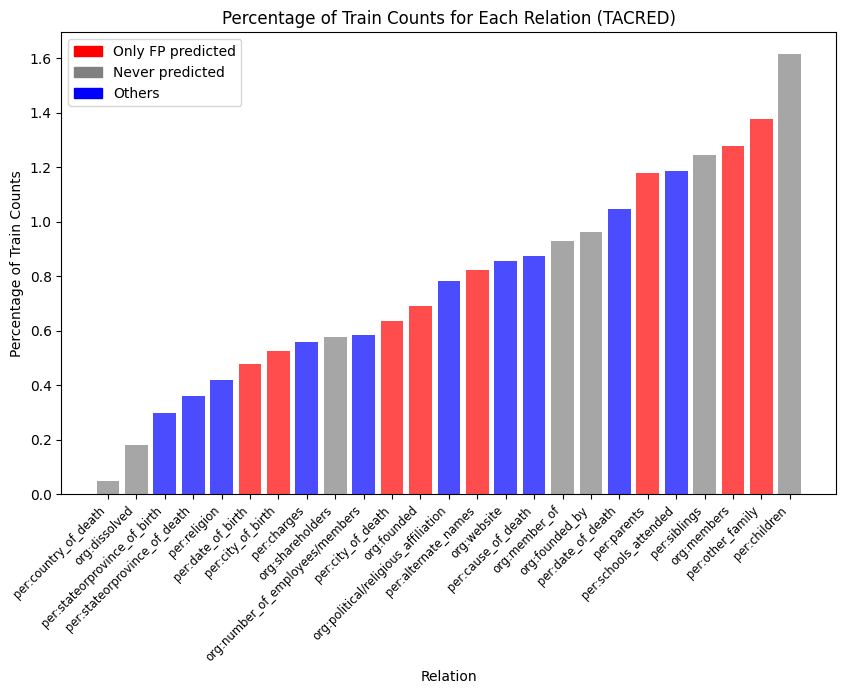

In [55]:
# Set the figure size
df = summary_data
df.sort_values(by="train_%", ascending=True, inplace=True)

# Define colors based on the conditions for precision and recall
colors = []

for index, row in df.iterrows():
    if row["Precision"] == 0 and row["Recall"] == 0:
        colors.append("red")
    elif row["Precision"] == 1 and row["Recall"] == 0:
        colors.append("gray")
    else:
        colors.append("blue")

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot the bars for train percentage with colors
bar_positions = range(len(df["Relation"][0:25]))
bars = plt.bar(bar_positions[0:25], (df["train_%"][0:25]), color=colors, alpha=0.7)

# Set the x-axis ticks and labels with rotation
plt.xticks(
    bar_positions, df["Relation"][0:25], rotation=45, ha="right", fontsize="small"
)

# Set labels and title
plt.xlabel("Relation")
plt.ylabel("Percentage of Train Counts")
plt.title("Percentage of Train Counts for Each Relation (TACRED)")

# Custom legend
legend_handles = [
    Patch(color="red", label="Only FP predicted"),
    Patch(color="gray", label="Never predicted"),
    Patch(color="blue", label="Others"),
]

# Add legend with smaller font size
plt.legend(handles=legend_handles, loc="upper left")

# Show the plot
plt.show()

In [50]:
# Recall 0 (i.e. never predicted or never predicted correctly).
summary_data.loc[summary_data["Recall"] == 0,]

,Relation,Precision,Recall,F1,test_counts,train_counts,train_%,test_%
25,per:country_of_death,1.0,0.0,0.0,10,6,0.049448,0.320205
3,org:dissolved,1.0,0.0,0.0,1,22,0.181309,0.032020
26,per:date_of_birth,0.0,0.0,0.0,7,58,0.477996,0.224143
22,per:city_of_birth,0.0,0.0,0.0,6,64,0.527444,0.192123
11,org:shareholders,1.0,0.0,0.0,3,70,0.576891,0.096061
23,per:city_of_death,0.0,0.0,0.0,16,77,0.634581,0.512328
4,org:founded,0.0,0.0,0.0,37,84,0.692270,1.184758
17,per:alternate_names,0.0,0.0,0.0,1,100,0.824131,0.032020
6,org:member_of,1.0,0.0,0.0,4,113,0.931268,0.128082
5,org:founded_by,1.0,0.0,0.0,76,117,0.964233,2.433557


In [13]:
# Those that the model never output (i.e. precision 1 and recall 0)
summary_data.loc[(summary_data["Precision"] == 1) & (summary_data["Recall"] == 0),]

,Relation,Precision,Recall,F1,test_counts,train_counts,train_%,test_%
25,per:country_of_death,1.0,0.0,0.0,10,6,0.049448,0.320205
3,org:dissolved,1.0,0.0,0.0,1,22,0.181309,0.032020
36,per:stateorprovince_of_birth,1.0,0.0,0.0,7,36,0.296687,0.224143
37,per:stateorprovince_of_death,1.0,0.0,0.0,13,44,0.362617,0.416266
26,per:date_of_birth,1.0,0.0,0.0,7,58,0.477996,0.224143
11,org:shareholders,1.0,0.0,0.0,3,70,0.576891,0.096061
8,org:number_of_employees/members,1.0,0.0,0.0,14,71,0.585133,0.448287
23,per:city_of_death,1.0,0.0,0.0,16,77,0.634581,0.512328
4,org:founded,1.0,0.0,0.0,37,84,0.692270,1.184758
17,per:alternate_names,1.0,0.0,0.0,1,100,0.824131,0.032020


In [14]:
# Those that the model outputs, but are always assigned to the wrong relation
summary_data.loc[(summary_data["Precision"] == 0) & (summary_data["Recall"] == 0),]

,Relation,Precision,Recall,F1,test_counts,train_counts,train_%,test_%
22,per:city_of_birth,0.0,0.0,0.0,6,64,0.527444,0.192123
31,per:parents,0.0,0.0,0.0,86,143,1.178507,2.753762
9,org:parents,0.0,0.0,0.0,57,268,2.208670,1.825168
13,org:subsidiaries,0.0,0.0,0.0,31,278,2.291083,0.992635


# Extract precision recall and F1 using only the most frequent relations

In [15]:
most_frequent_5 = list(
    summary_data.sort_values(by="train_%", ascending=False)["Relation"][0:5]
)
print(f"The 5 most frequent relations are:\n{most_frequent_5}")
error_df_top5 = error_df.loc[
    error_df["Gold Label"].isin(most_frequent_5)
    | error_df["Prediction"].isin(most_frequent_5)
].reset_index(drop=True)
scorer.score(error_df_top5["Gold Label"], error_df_top5["Prediction"], verbose=False)

The 5 most frequent relations are:
['per:title', 'org:top_members/employees', 'per:employee_of', 'org:alternate_names', 'org:country_of_headquarters']
Precision (micro): 47.366%
   Recall (micro): 74.785%
       F1 (micro): 57.998%


C:\Users\Hp\AppData\Local\Temp\ipykernel_18348\310135781.py:1: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  most_frequent_5 = list(summary_data.sort_values(by='train_%', ascending=False)['Relation'][0:5])


(0.4736622073578595, 0.7478547854785479, 0.5799846429485539)

### Construct dataset with text for error analysis

In [19]:
# Import the original test data
with open("../../../data/tacred/json/test.json", "r") as file:
    data_test = json.load(file)
test_data = pd.json_normalize(data_test)
test_data["predicted"] = error_df["Prediction"]

In [20]:
test_data["sentence_length"] = [
    len(test_data["token"][i]) for i in range(len(test_data))
]
test_data["entity_distance"] = [
    (test_data["subj_start"][i] - test_data["obj_end"][i])
    if test_data["subj_start"][i] > test_data["obj_end"][i]
    else (test_data["obj_start"][i] - test_data["subj_end"][i])
    for i in range(len(test_data))
]

### Analyse the behaviour at different sentence length


(array([ 499., 2200., 3866., 4279., 2888., 1085.,  394.,  144.,   93.,
          61.]),
 array([ 4. , 13.2, 22.4, 31.6, 40.8, 50. , 59.2, 68.4, 77.6, 86.8, 96. ]),
 <BarContainer object of 10 artists>)

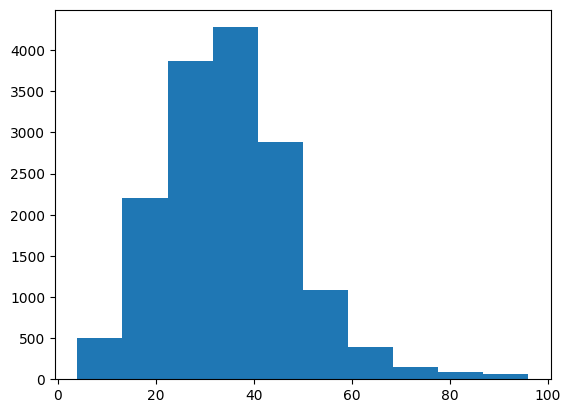

In [21]:
plt.hist(
    test_data["sentence_length"]
)  # Split into 3 groups and obtain F1 score on each

In [22]:
q1_sl = test_data["sentence_length"].quantile(0.3333)
q2_sl = test_data["sentence_length"].quantile(0.6666)

In [23]:
test_data["sentence_length_categorical"] = [
    "short"
    if test_data["sentence_length"][i] < q1_sl
    else ["long" if test_data["sentence_length"][i] > q2_sl else "medium"][0]
    for i in range(len(test_data))
]

In [24]:
# Now obtain the F1 score on each of the three splits, along with the average precision
for length in ["short", "medium", "long"]:
    predicted_length = test_data["predicted"][
        test_data["sentence_length_categorical"] == length
    ]
    exact_length = test_data["relation"][
        test_data["sentence_length_categorical"] == length
    ]
    print(
        f"Results on sentences of {length} length ({len(predicted_length)}) instances"
    )
    scorer.score(list(exact_length), list(predicted_length))

Results on sentences of short length (4821) instances
Precision (micro): 40.999%
   Recall (micro): 47.489%
       F1 (micro): 44.006%
Results on sentences of medium length (5581) instances
Precision (micro): 48.039%
   Recall (micro): 46.701%
       F1 (micro): 47.361%
Results on sentences of long length (5107) instances
Precision (micro): 48.272%
   Recall (micro): 42.775%
       F1 (micro): 45.358%


### Analyse the behaviour at different distances between entities


(array([8.100e+03, 4.114e+03, 1.855e+03, 9.370e+02, 3.250e+02, 1.260e+02,
        2.900e+01, 1.400e+01, 4.000e+00, 5.000e+00]),
 array([ 1. ,  9.2, 17.4, 25.6, 33.8, 42. , 50.2, 58.4, 66.6, 74.8, 83. ]),
 <BarContainer object of 10 artists>)

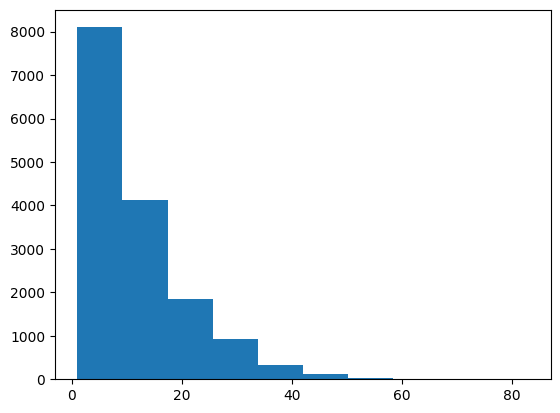

In [25]:
plt.hist(test_data["entity_distance"])

In [26]:
q1_ed = test_data["entity_distance"].quantile(0.3333)
q2_ed = test_data["entity_distance"].quantile(0.6666)

In [27]:
test_data["entity_distance_categorical"] = [
    "short"
    if test_data["entity_distance"][i] < q1_ed
    else ["long" if test_data["entity_distance"][i] > q2_ed else "medium"][0]
    for i in range(len(test_data))
]

In [28]:
# Now obtain the F1 score on each of the three splits, along with the average precision
for distance in ["short", "medium", "long"]:
    predicted_distance = test_data["predicted"][
        test_data["entity_distance_categorical"] == distance
    ]
    exact_distance = test_data["relation"][
        test_data["entity_distance_categorical"] == distance
    ]
    print(
        f"Results on sentences with entity distance {distance} ({len(predicted_distance)}) instances"
    )
    scorer.score(list(exact_distance), list(predicted_distance))

Results on sentences with entity distance short (4946) instances
Precision (micro): 60.086%
   Recall (micro): 56.845%
       F1 (micro): 58.420%
Results on sentences with entity distance medium (5565) instances
Precision (micro): 37.489%
   Recall (micro): 42.166%
       F1 (micro): 39.690%
Results on sentences with entity distance long (4998) instances
Precision (micro): 19.846%
   Recall (micro): 18.166%
       F1 (micro): 18.969%


Also consider how they are affected when both of them are considered.

In [29]:
# Now obtain the F1 score on each of the three splits, along with the average precision

f1s = []
precisions = []
recalls = []
counts = []
distances = [
    "short",
    "short",
    "short",
    "medium",
    "medium",
    "medium",
    "long",
    "long",
    "long",
]
lengths = [
    "short",
    "medium",
    "long",
    "short",
    "medium",
    "long",
    "short",
    "medium",
    "long",
]
# Now obtain the F1 score on each of the three splits, along with the average precision
for distance in ["short", "medium", "long"]:
    for length in ["short", "medium", "long"]:
        predicted = test_data["predicted"][
            (test_data["sentence_length_categorical"] == length)
            & (test_data["entity_distance_categorical"] == distance)
        ]
        exact = test_data["relation"][
            (test_data["sentence_length_categorical"] == length)
            & (test_data["entity_distance_categorical"] == distance)
        ]
        print(
            f"Results on sentences of {length} length and with distance {distance} between densities ({len(predicted)}) instances"
        )
        counts.append(len(predicted))
        out = scorer.score(list(exact), list(predicted))
        f1s.append(out[2])
        precisions.append(out[0])
        recalls.append(out[1])

Results on sentences of short length and with distance short between densities (2113) instances
Precision (micro): 51.313%
   Recall (micro): 52.509%
       F1 (micro): 51.904%
Results on sentences of medium length and with distance short between densities (1662) instances
Precision (micro): 62.639%
   Recall (micro): 58.284%
       F1 (micro): 60.383%
Results on sentences of long length and with distance short between densities (1171) instances
Precision (micro): 67.981%
   Recall (micro): 59.796%
       F1 (micro): 63.626%
Results on sentences of short length and with distance medium between densities (2030) instances
Precision (micro): 31.398%
   Recall (micro): 43.116%
       F1 (micro): 36.336%
Results on sentences of medium length and with distance medium between densities (2008) instances
Precision (micro): 39.407%
   Recall (micro): 41.704%
       F1 (micro): 40.523%
Results on sentences of long length and with distance medium between densities (1527) instances
Precision (micro

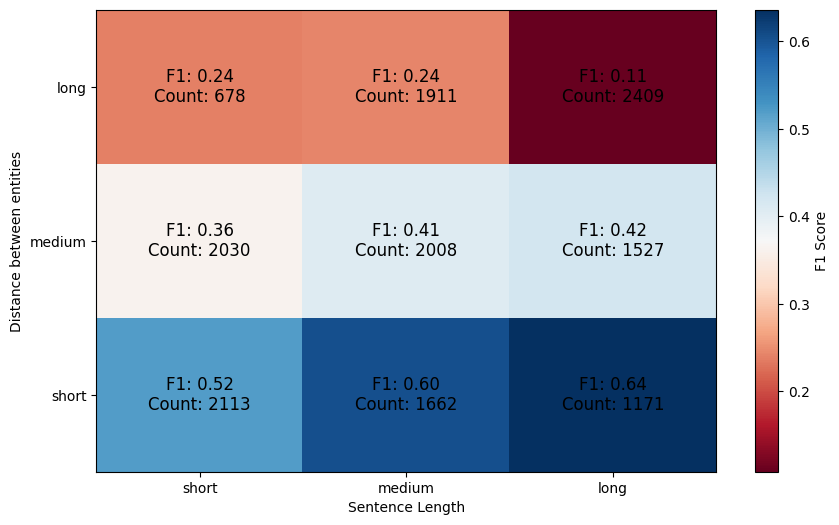

In [30]:
results_data = {
    "distance": distances,
    "length": lengths,
    "f1_score": f1s,
    "precision": precisions,
    "recall": recalls,
    "counts": counts,
}

results_df = pd.DataFrame(results_data)

# Reshape the DataFrame for heatmap
heatmap_data_f1 = results_df.pivot(
    index="distance", columns="length", values="f1_score"
)
heatmap_data_f1 = heatmap_data_f1.iloc[:, ::-1]
heatmap_data_f1 = heatmap_data_f1[::-1]

# Plot the heatmap for F1 Score with count annotations using a diverging color scale
plt.figure(figsize=(10, 6))
heatmap = plt.imshow(
    heatmap_data_f1,
    cmap="RdBu",
    interpolation="nearest",
    aspect="auto",
    vmin=heatmap_data_f1.values.min(),
    vmax=heatmap_data_f1.values.max(),
    origin="lower",
)

# Annotate each tile with the count
for i in range(len(heatmap_data_f1.index)):
    for j in range(len(heatmap_data_f1.columns)):
        count_value = results_df[
            (results_df["distance"] == heatmap_data_f1.index[i])
            & (results_df["length"] == heatmap_data_f1.columns[j])
        ]["counts"].values[0]
        plt.text(
            j,
            i,
            f"F1: {heatmap_data_f1.iloc[i, j]:.2f}\nCount: {count_value}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

plt.colorbar(heatmap, label="F1 Score")
plt.xticks(np.arange(len(heatmap_data_f1.columns)), heatmap_data_f1.columns)
plt.yticks(np.arange(len(heatmap_data_f1.index)), heatmap_data_f1.index)
plt.xlabel("Sentence Length")
plt.ylabel("Distance between entities")
plt.title("")
plt.show()